<a href="https://colab.research.google.com/github/Darshana9priya99/Machine-Learning-experiments/blob/main/Experiment-01/DarshanaPriya_ML_Experiment1_PolynomialRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_excel("ENB2012_data.xlsx")

In [ ]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
df.shape

(768, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [ ]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [ ]:
df.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


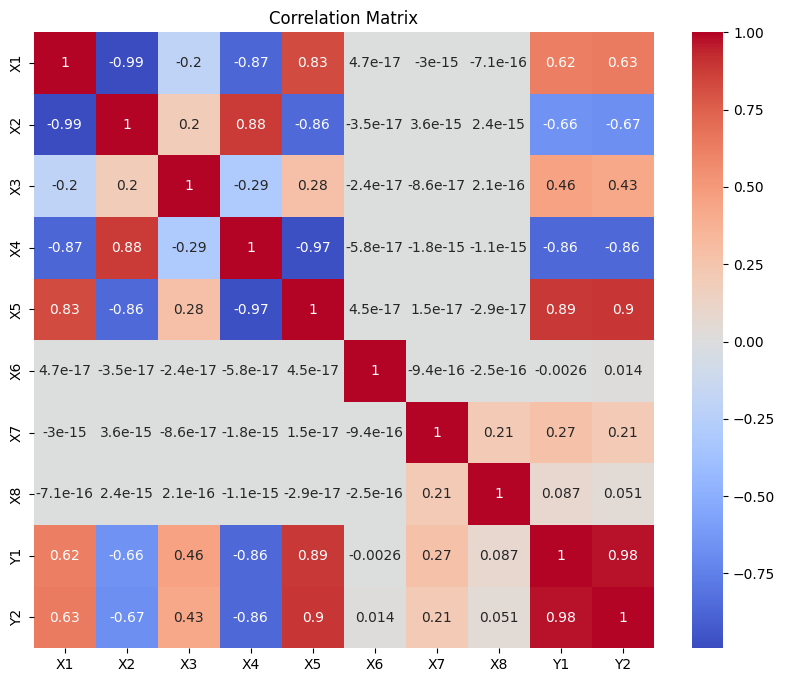

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

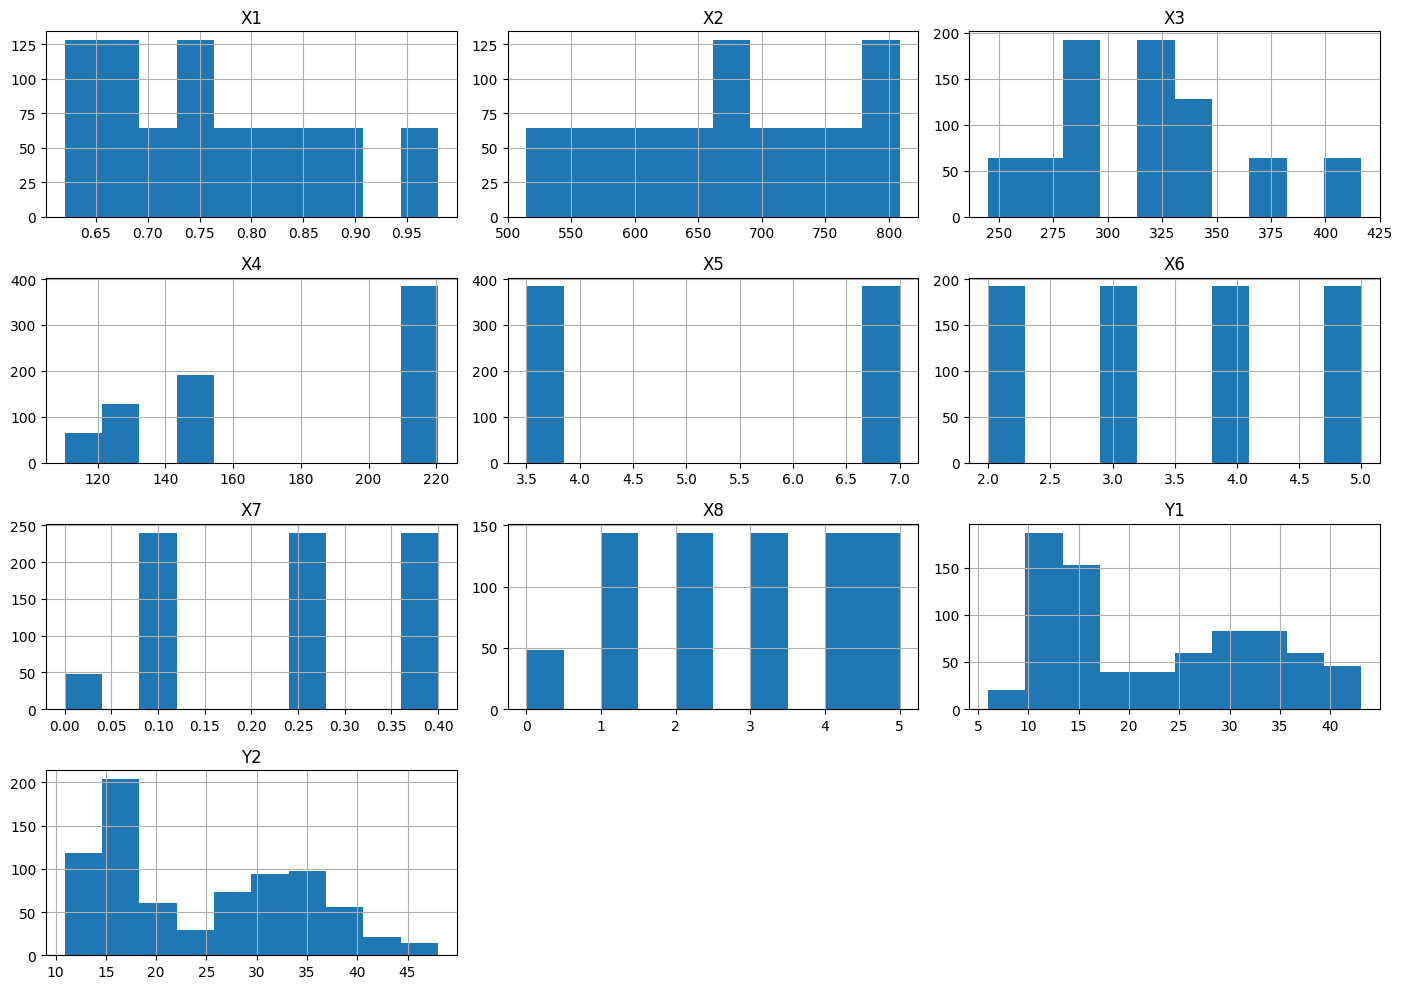

In [ ]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

In [ ]:
X = df.iloc[:,0:8]
y = df.iloc[:,8]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
train_mse = []
test_mse = []
train_rmse = []
test_rmse = []
mae_list = []
r2_list = []

degrees = range(1,11)

for degree in degrees:

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_error = mean_squared_error(y_train, train_pred)
    test_error = mean_squared_error(y_test, test_pred)

    train_mse.append(train_error)
    test_mse.append(test_error)

    train_rmse.append(np.sqrt(train_error))
    test_rmse.append(np.sqrt(test_error))

    mae_list.append(mean_absolute_error(y_test,test_pred))
    r2_list.append(r2_score(y_test,test_pred))

In [ ]:
results = pd.DataFrame({
    "Degree":degrees,
    "Train MSE":train_mse,
    "Test MSE":test_mse,
    "Train RMSE":train_rmse,
    "Test RMSE":test_rmse,
    "MAE":mae_list,
    "R²":r2_list
})

results.round(4)

,Degree,Train MSE,Test MSE,Train RMSE,Test RMSE,MAE,R²
0,1,8.3701,9.1532,2.8931,3.0254,2.1821,0.9122
1,2,0.4868,0.6447,0.6977,0.8030,0.6042,0.9938
2,3,0.1636,0.2948,0.4045,0.5430,0.4111,0.9972
3,4,0.1123,0.2298,0.3350,0.4794,0.3582,0.9978
4,5,0.1111,0.2257,0.3333,0.4750,0.3552,0.9978
5,6,0.1260,0.2722,0.3550,0.5218,0.3870,0.9974
6,7,0.1461,0.2905,0.3823,0.5389,0.3977,0.9972
7,8,0.1727,0.3348,0.4156,0.5786,0.4204,0.9968
8,9,0.1912,0.3694,0.4372,0.6078,0.4382,0.9965
9,10,0.3199,0.5877,0.5656,0.7666,0.5660,0.9944


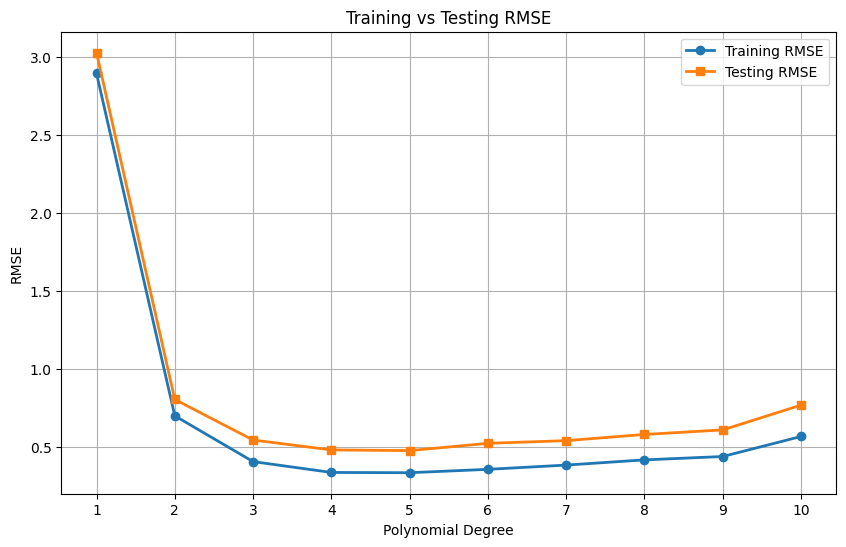

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(degrees, train_rmse, marker='o', linewidth=2, label='Training RMSE')

plt.plot(degrees, test_rmse, marker='s', linewidth=2, label='Testing RMSE')

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Training vs Testing RMSE")

plt.xticks(range(1,11))
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
best_index = np.argmin(test_rmse)

best_degree = degrees[best_index]

print("Best Polynomial Degree :", best_degree)

print(results.iloc[best_index])

Best Polynomial Degree : 5
Degree        5.000000
Train MSE     0.111068
Test MSE      0.225665
Train RMSE    0.333268
Test RMSE     0.475042
MAE           0.355209
R²            0.997835
Name: 4, dtype: float64


In [ ]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Best Polynomial Regression"],
    "Degree":[1,best_degree],
    "RMSE":[test_rmse[0],test_rmse[best_index]],
    "MAE":[mae_list[0],mae_list[best_index]],
    "R²":[r2_list[0],r2_list[best_index]]
})

comparison.round(4)

,Model,Degree,RMSE,MAE,R²
0,Linear Regression,1,3.0254,2.1821,0.9122
1,Best Polynomial Regression,5,0.4750,0.3552,0.9978


In [ ]:
print("Best Polynomial Degree :", best_degree)
print("Lowest Test RMSE :", round(test_rmse[best_index],4))
print("MAE :", round(mae_list[best_index],4))
print("R² Score :", round(r2_list[best_index],4))

Best Polynomial Degree : 5
Lowest Test RMSE : 0.475
MAE : 0.3552
R² Score : 0.9978


In [ ]:
print(f"""
Conclusion

1. Polynomial Regression models from degree 1 to 10 were trained successfully.

2. Degree {best_degree} achieved the lowest testing RMSE.

3. Higher polynomial degrees may lead to overfitting as training error decreases while testing error increases.

4. The best polynomial model outperformed the basic linear regression model.

5. Therefore, Polynomial Degree {best_degree} is selected as the optimal model for this dataset.
""")


Conclusion

1. Polynomial Regression models from degree 1 to 10 were trained successfully.

2. Degree 5 achieved the lowest testing RMSE.

3. Higher polynomial degrees may lead to overfitting as training error decreases while testing error increases.

4. The best polynomial model outperformed the basic linear regression model.

5. Therefore, Polynomial Degree 5 is selected as the optimal model for this dataset.

